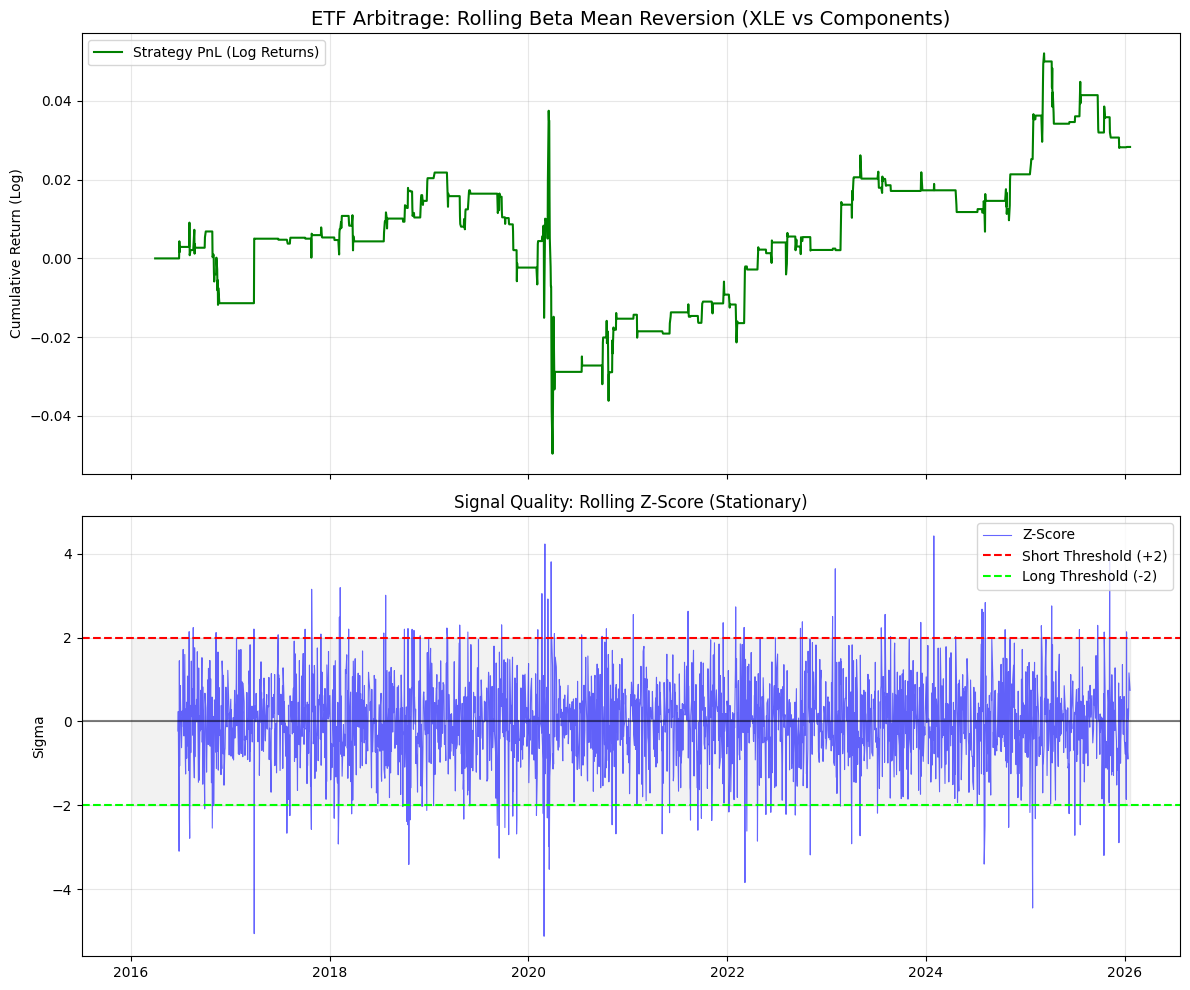

Total Return: 2.87%
Sharpe Ratio: 0.11


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA INGESTION (Energy Sector)
# ==========================================
def get_energy_data():
    # We use Energy because it is physically cointegrated (Oil Price)
    # Tech (QQQ) is too idiosyncratic for pure mean reversion
    tickers = ['XOM', 'CVX', 'EOG', 'SLB', 'COP']
    etf = 'XLE'
    
    print(f"Downloading {etf} and {len(tickers)} components...")
    data = yf.download(tickers + [etf], start="2016-01-01", progress=False)['Close']
    
    # Drop NaNs to ensure alignment
    data = data.dropna()
    data.rename(columns={etf: 'ETF_PROXY'}, inplace=True)
    return data

# ==========================================
# 2. THE STRATEGY (Vectorized)
# ==========================================
def run_strategy(prices_df, window=60, entry_z=2.0, exit_z=0.5):
    """
    Calculates the PnL of a Rolling Beta Z-Score Strategy.
    """
    # A. Calculate Log Returns (Additive)
    rets = np.log(prices_df / prices_df.shift(1))
    
    etf_col = 'ETF_PROXY'
    components = [c for c in rets.columns if c != etf_col]
    
    # B. Define Basket (Equal Weight Return of Components)
    basket_ret = rets[components].mean(axis=1)
    etf_ret = rets[etf_col]
    
    # C. Rolling Beta (The Hedge Ratio)
    # Beta = Covariance(ETF, Basket) / Variance(Basket)
    # This adjusts for the fact that the ETF might be 1.5x more volatile than the basket
    rolling_cov = etf_ret.rolling(window).cov(basket_ret)
    rolling_var = basket_ret.rolling(window).var()
    rolling_beta = rolling_cov / rolling_var
    
    # D. The "Idiosyncratic Spread" (Signal)
    # Spread = Actual ETF Ret - (Beta * Basket Ret)
    spread_ret = etf_ret - (rolling_beta * basket_ret)
    
    # E. Rolling Z-Score
    z_score = (spread_ret - spread_ret.rolling(window).mean()) / spread_ret.rolling(window).std()
    
    # F. Signal Generation
    # 1 = Long Spread (Buy ETF / Sell Basket)
    # -1 = Short Spread (Sell ETF / Buy Basket)
    # 0 = Exit/Flat
    positions = pd.Series(0, index=z_score.index)
    
    # Entry Logic
    positions[z_score < -entry_z] = 1  # ETF is Cheap -> Buy
    positions[z_score > entry_z] = -1  # ETF is Expensive -> Sell
    
    # Exit Logic (Mean Reversion)
    # If |Z| < 0.5, we want to be flat (0).
    # However, between 0.5 and 2.0, we want to HOLD previous position.
    # Vectorized "Hold" logic: Forward fill positions, but force 0 at exits.
    
    # 1. Mark Exits
    positions[abs(z_score) < exit_z] = 0
    
    # 2. Forward Fill (Replace 0s that aren't exits? No, simpler to fill NaNs)
    # Trick: Set non-entries/exits to NaN, then ffill
    # This preserves the "Hold" state between Signal and Exit
    signal_logic = positions.replace(0, np.nan) # 0 is currently default, not explicit exit
    
    # Re-apply explicit exits as 0
    signal_logic[abs(z_score) < exit_z] = 0
    
    # Now ffill to carry the trade through the "middle zone"
    final_positions = signal_logic.ffill().fillna(0)
    
    # G. PnL Calculation
    # SHIFT(1) IS CRITICAL: We trade tomorrow based on today's Z-Score
    lagged_pos = final_positions.shift(1)
    
    # Strategy Return = Position * Spread Return
    strat_ret = lagged_pos * spread_ret
    
    # Transaction Costs (Approx 1bps per trade turnover)
    # trade_turnover = abs(lagged_pos.diff())
    # costs = trade_turnover * 0.0001
    # strat_ret = strat_ret - costs
    
    return strat_ret.cumsum(), z_score

# ==========================================
# 3. EXECUTION
# ==========================================
# 1. Get Data
df = get_energy_data()

# 2. Run Strategy
equity_curve, z_score_history = run_strategy(df)

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top Plot: Equity Curve
ax1.plot(equity_curve, color='green', linewidth=1.5, label='Strategy PnL (Log Returns)')
ax1.set_title('ETF Arbitrage: Rolling Beta Mean Reversion (XLE vs Components)', fontsize=14)
ax1.set_ylabel('Cumulative Return (Log)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Bottom Plot: The Z-Score Heartbeat
ax2.plot(z_score_history, color='blue', alpha=0.6, linewidth=0.8, label='Z-Score')
ax2.axhline(2.0, color='red', linestyle='--', label='Short Threshold (+2)')
ax2.axhline(-2.0, color='lime', linestyle='--', label='Long Threshold (-2)')
ax2.axhline(0, color='black', alpha=0.5)
ax2.fill_between(z_score_history.index, 2, -2, color='gray', alpha=0.1)
ax2.set_title('Signal Quality: Rolling Z-Score (Stationary)', fontsize=12)
ax2.set_ylabel('Sigma')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats
total_return = np.exp(equity_curve.iloc[-1]) - 1
sharpe = equity_curve.diff().mean() / equity_curve.diff().std() * np.sqrt(252)
print(f"Total Return: {total_return*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")